In [1]:
import pandas as pd
import numpy as np
import glob
from tqdm.auto import tqdm

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision.transforms import transforms
import pathlib
from torch.optim.lr_scheduler import ExponentialLR
from torchviz import make_dot

import pytorch_lightning as pl

import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib
from matplotlib.ticker import MaxNLocator

from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
from torchmetrics.functional import accuracy

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

import datetime
import time
import random
import os


# setting device on GPU if available, else CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Additional Info when using cuda
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

/home/lisa/anaconda3/envs/agg_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:0

NVIDIA RTX A6000
Memory Usage:
Allocated: 0.0 GB
Cached:    0.0 GB


In [2]:
class GRU(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, num_layers=2, num_classes=5):
        super(GRU, self).__init__()

        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_dim, num_classes)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        # x comes in as (batch, 1, 20, 10)
        # Remove the unnecessary channel dimension
        x = x.squeeze(1)              # shape → (batch, 20, 10)

        out, hidden = self.gru(x)     # GRU accepts (batch, seq_len=20, input_dim=10)

        out = out[:, -1, :]           # last timestep output
        out = self.fc(out)
        return self.softmax(out)

In [3]:
def load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42,
    drop_last_train=True
):
    if not os.path.exists(npz_path):
        raise FileNotFoundError(f"NPZ not found: {os.path.abspath(npz_path)}")

    data = np.load(npz_path)
    required = {"X_train", "y_train", "X_test", "y_test"}
    if not required.issubset(set(data.files)):
        raise KeyError(f"NPZ must contain {sorted(required)}. Found: {data.files}")

    # Train tensors
    X_train = torch.from_numpy(data["X_train"]).float()
    y_train = torch.from_numpy(data["y_train"]).long()
    train_dataset = TensorDataset(X_train, y_train)

    # Test tensors
    X_test = torch.from_numpy(data["X_test"]).float()
    y_test = torch.from_numpy(data["y_test"]).long()
    test_dataset = TensorDataset(X_test, y_test)

    # Deterministic shuffle for train
    generator = None
    if shuffle_train:
        generator = torch.Generator()
        generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        generator=generator,
        drop_last=drop_last_train
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )

    return train_loader, test_loader

In [4]:
# usage
npz_path = "Prepared/Tesla_human_train_test_chunks.npz"
train_loader, test_loader = load_train_test_loaders_from_npz(
    npz_path,
    batch_size=64,
    shuffle_train=True,
    seed=42
)

# sanity check
x_tr, y_tr = next(iter(train_loader))
x_te, y_te = next(iter(test_loader))
print("Train batch:", x_tr.shape, y_tr.shape)
print("Test  batch:", x_te.shape, y_te.shape)
print("Train labels unique (batch):", torch.unique(y_tr))
print("Test  labels unique (batch):", torch.unique(y_te))

Train batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Test  batch: torch.Size([64, 1, 20, 10]) torch.Size([64])
Train labels unique (batch): tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Test  labels unique (batch): tensor([0, 2, 3, 4, 5, 6, 7, 8, 9])


In [5]:
model = GRU(num_classes=10)

# Define the loss function (e.g., cross-entropy loss)
criterion = nn.CrossEntropyLoss()

# Choose an optimizer (e.g., Adam optimizer)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Set the device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

GRU(
  (gru): GRU(10, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=10, bias=True)
  (softmax): LogSoftmax(dim=1)
)

In [7]:
# Initialize variables for early stopping
best_val_loss = np.Inf
patience = 10
counter = 0
num_epochs = 50

model.to(device)

train_dataset_len = len(train_loader.dataset)
test_dataset_len = len(test_loader.dataset)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # -------------------------------
    # TRAINING
    # -------------------------------
    for inputs, labels in train_loader:

        # FIX: convert to float + move to device
        inputs = inputs.float().to(device)    # (batch, 20, 10)
        labels = labels.long().to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_loss / train_dataset_len

    # -------------------------------
    # VALIDATION
    # -------------------------------
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for val_inputs, val_labels in test_loader:

            # FIX: convert to float + move to device
            val_inputs = val_inputs.float().to(device)
            val_labels = val_labels.long().to(device)

            val_outputs = model(val_inputs)
            val_loss = criterion(val_outputs, val_labels)

            running_val_loss += val_loss.item() * val_inputs.size(0)

            _, predicted = torch.max(val_outputs, 1)
            total += val_labels.size(0)
            correct += (predicted == val_labels).sum().item()

    epoch_val_loss = running_val_loss / test_dataset_len
    val_accuracy = correct / total

    print(f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {epoch_train_loss:.4f}, "
        f"Val Loss: {epoch_val_loss:.4f}, "
        f"Val Accuracy: {val_accuracy:.2%}")

    # -------------------------------
    # EARLY STOPPING & SAVE
    # -------------------------------
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0
        #torch.save(model.state_dict(), "models/Tesla_GRU_20_Over_50.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break

Epoch [1/50] Train Loss: 0.2975, Val Loss: 0.2499, Val Accuracy: 89.21%
Epoch [2/50] Train Loss: 0.2090, Val Loss: 0.1452, Val Accuracy: 94.25%
Epoch [3/50] Train Loss: 0.1393, Val Loss: 0.1851, Val Accuracy: 92.44%
Epoch [4/50] Train Loss: 0.1053, Val Loss: 0.0794, Val Accuracy: 97.03%
Epoch [5/50] Train Loss: 0.0810, Val Loss: 0.0635, Val Accuracy: 97.70%
Epoch [6/50] Train Loss: 0.0647, Val Loss: 0.0647, Val Accuracy: 97.64%
Epoch [7/50] Train Loss: 0.0532, Val Loss: 0.0461, Val Accuracy: 98.24%
Epoch [8/50] Train Loss: 0.0486, Val Loss: 0.0654, Val Accuracy: 97.74%
Epoch [9/50] Train Loss: 0.0454, Val Loss: 0.0449, Val Accuracy: 98.47%
Epoch [10/50] Train Loss: 0.0337, Val Loss: 0.0339, Val Accuracy: 98.76%
Epoch [11/50] Train Loss: 0.0320, Val Loss: 0.0506, Val Accuracy: 98.08%
Epoch [12/50] Train Loss: 0.0350, Val Loss: 0.0271, Val Accuracy: 99.02%
Epoch [13/50] Train Loss: 0.0266, Val Loss: 0.0493, Val Accuracy: 98.39%
Epoch [14/50] Train Loss: 0.0230, Val Loss: 0.0275, Val Accu

## Test Model

In [1]:
import torch
from sklearn.metrics import confusion_matrix
from src.GRU import GRU
from src.inference import LoadTestData, GetPrediction, GetProbsAndLabels
from src.metrics import PlotConfusionMatrix, ComputeFullMetrics, PlotPRCurve

In [2]:
# ---------- 4) Load model weights ----------
def LoadModel(ckpt_path, device, num_classes=10):
    model = GRU(num_classes=num_classes)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state)
    return model

In [3]:
# ---------- 5) Run prediction ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "models/Tesla_GRU_20_Over_50.pth"
npz_path = "Prepared/Tesla_human_train_test_chunks.npz"
test_loader = LoadTestData(npz_path, batch_size=64)
model = LoadModel(ckpt_path, device=device, num_classes=10)

In [4]:
pred = GetPrediction(model, test_loader, device)
y_pred = pred[0]
y_test = pred[1]
cf_matrix = confusion_matrix(y_test, y_pred)

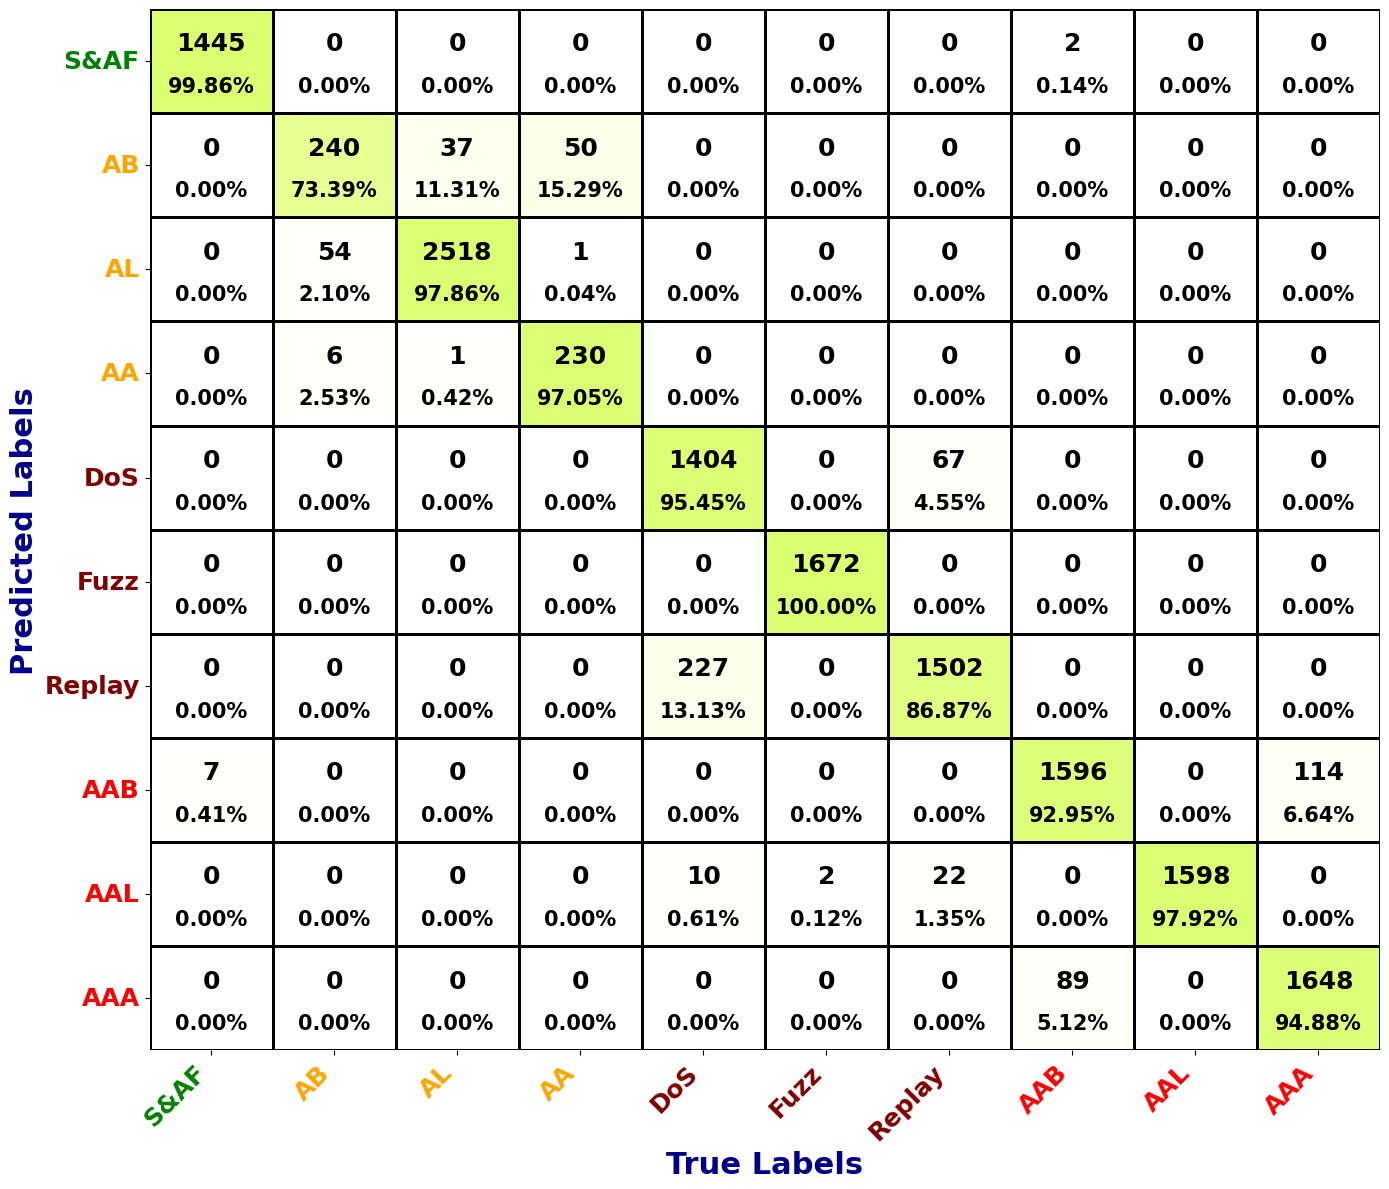

In [5]:
# --- Updated class labels --- #
class_labels = ["S&AF", "AB", "AL", "AA", "DoS", "Fuzz", "Replay", "AAB", "AAL", "AAA"]
PlotConfusionMatrix(cf_matrix, class_labels)

In [6]:
stats_df = ComputeFullMetrics(cf_matrix, class_labels)
stats_df

,Class,Support,Precision,Recall,F1,Accuracy,Error_Rate,CI_Lower,CI_Upper,AUC
0,S&AF,1447,0.9952,0.9986,0.9969,0.9986,0.0014,0.9950,0.9996,1.0
1,AB,327,0.8000,0.7339,0.7656,0.7339,0.2661,0.6835,0.7789,1.0
2,AL,2573,0.9851,0.9786,0.9819,0.9786,0.0214,0.9723,0.9835,1.0
3,AA,237,0.8185,0.9705,0.8880,0.9705,0.0295,0.9403,0.9856,1.0
4,DoS,1471,0.8556,0.9545,0.9023,0.9545,0.0455,0.9426,0.9640,1.0
5,Fuzz,1672,0.9988,1.0000,0.9994,1.0000,0.0000,0.9977,1.0000,1.0
6,Replay,1729,0.9441,0.8687,0.9048,0.8687,0.1313,0.8520,0.8838,1.0
7,AAB,1717,0.9461,0.9295,0.9377,0.9295,0.0705,0.9164,0.9407,1.0
8,AAL,1632,1.0000,0.9792,0.9895,0.9792,0.0208,0.9710,0.9851,1.0
9,AAA,1737,0.9353,0.9488,0.9420,0.9488,0.0512,0.9374,0.9582,1.0


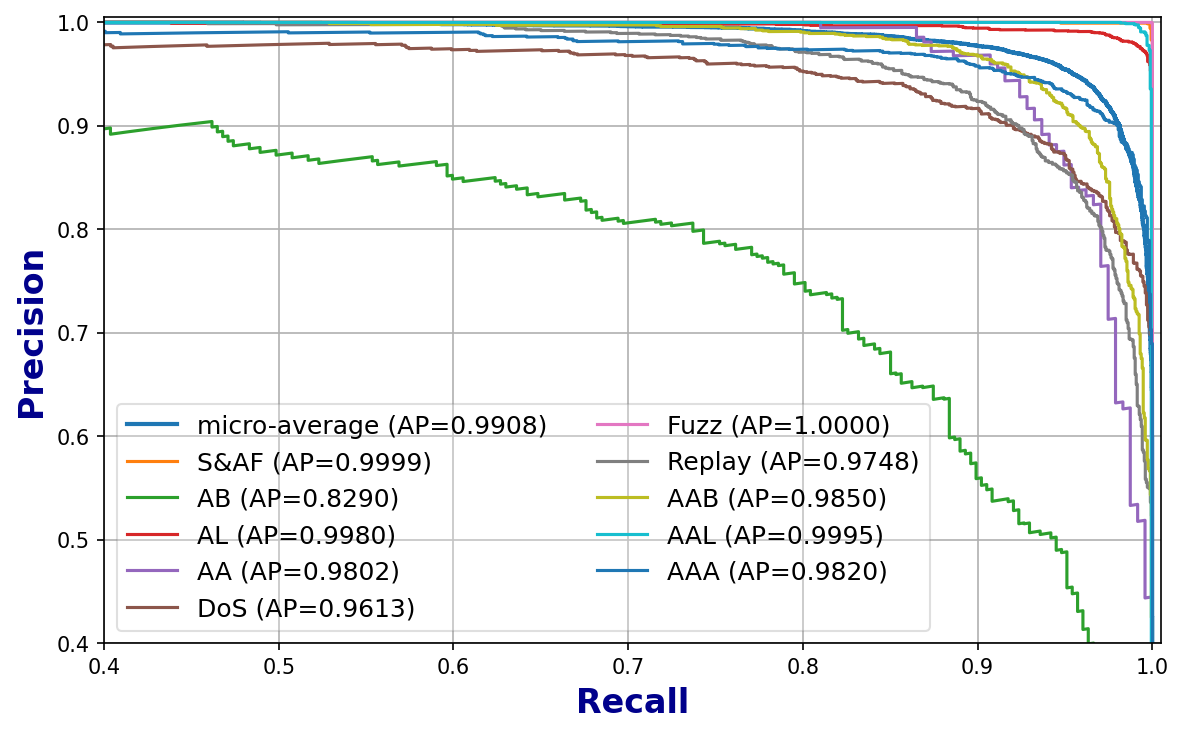

{'AP_micro': 0.990758610604441,
 'AP_macro': 0.9709824068781228,
 'AP_per_class': {'S&AF': 0.9999472146515758,
  'AB': 0.8290466303224383,
  'AL': 0.9980346128816109,
  'AA': 0.9801628875153509,
  'DoS': 0.9613225529604214,
  'Fuzz': 0.9999996425067995,
  'Replay': 0.9748479573810308,
  'AAB': 0.9850042255109908,
  'AAL': 0.9994721297457134,
  'AAA': 0.9819862153052965}}

In [11]:
y_test, y_score = GetProbsAndLabels(model, test_loader, device)
PlotPRCurve(
    y_true=y_test,
    y_score=y_score,
    class_labels=["S&AF","AB","AL","AA","DoS","Fuzz","Replay","AAB","AAL","AAA"],
    xlim=(0.40, 1.005),
    ylim=(0.40, 1.005),
)